In [1]:
import pandas as pd
from pathlib import Path

DATA = Path("../../data")

def load_csvs(prefix):
    files = sorted(DATA.glob(f"{prefix}-*.csv"))
    frames = []
    for file in files:
        print(f"📥 Lendo arquivo: {file.name}")
        df = pd.read_csv(file, sep=";", quotechar='"', low_memory=False)
        df["ano"] = int(file.stem.split("-")[-1])  # adiciona coluna de ano
        print(f"✅ Linhas: {len(df)} | Colunas: {list(df.columns)}")
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

# Carregamento
votacoes = load_csvs("voting/votacoes")
votos = load_csvs("voting/votes/votacoesVotos")

# 🔎 Verificação das colunas esperadas
print("\n🔍 Estrutura dos dados carregados:")

print("\n📘 votacoes:")
print(votacoes.head(2))
print("🧩 Colunas votacoes:", votacoes.columns.tolist())

print("\n📗 votos:")
print(votos.head(2))
print("🧩 Colunas votos:", votos.columns.tolist())

# 🔎 Valores únicos para votos
if "voto" in votos.columns:
    print("🗳️ Votos únicos:", votos["voto"].dropna().unique())

# 🔎 Verificar se 'aprovacao' está em votacoes
if "aprovacao" in votacoes.columns:
    print("📊 Valores únicos de 'aprovacao':", votacoes["aprovacao"].dropna().unique())
else:
    print("⚠️ Coluna 'aprovacao' não encontrada em votacoes!")

# 🔎 Verificação de chaves de junção
if "id" in votacoes.columns and "idVotacao" in votos.columns:
    print("🔑 Pronto para fazer merge entre votos e votacoes usando 'idVotacao' e 'id'")
else:
    print("⚠️ Verifique se 'idVotacao' e 'id' existem para fazer o merge corretamente.")


📥 Lendo arquivo: votacoes-2003.csv
✅ Linhas: 10128 | Colunas: ['id', 'uri', 'data', 'dataHoraRegistro', 'idOrgao', 'uriOrgao', 'siglaOrgao', 'idEvento', 'uriEvento', 'aprovacao', 'votosSim', 'votosNao', 'votosOutros', 'descricao', 'ultimaAberturaVotacao_dataHoraRegistro', 'ultimaAberturaVotacao_descricao', 'ultimaApresentacaoProposicao_dataHoraRegistro', 'ultimaApresentacaoProposicao_descricao', 'ultimaApresentacaoProposicao_idProposicao', 'ultimaApresentacaoProposicao_uriProposicao', 'ano']
📥 Lendo arquivo: votacoes-2004.csv
✅ Linhas: 6783 | Colunas: ['id', 'uri', 'data', 'dataHoraRegistro', 'idOrgao', 'uriOrgao', 'siglaOrgao', 'idEvento', 'uriEvento', 'aprovacao', 'votosSim', 'votosNao', 'votosOutros', 'descricao', 'ultimaAberturaVotacao_dataHoraRegistro', 'ultimaAberturaVotacao_descricao', 'ultimaApresentacaoProposicao_dataHoraRegistro', 'ultimaApresentacaoProposicao_descricao', 'ultimaApresentacaoProposicao_idProposicao', 'ultimaApresentacaoProposicao_uriProposicao', 'ano']
📥 Lendo

In [2]:
# 🔄 Etapa 1 – Merge para incluir 'aprovacao' em votos
votos = votos.merge(
    votacoes[["id", "aprovacao"]],
    left_on="idVotacao",
    right_on="id",
    how="left"
)

# 🔎 Verificação pós-merge
print("\n📎 Verificação pós-merge:")
print(votos[["idVotacao", "voto", "aprovacao"]].dropna().head())
print("Valores únicos de 'aprovacao' pós-merge:", votos["aprovacao"].dropna().unique())

# 🔄 Etapa 2 – Limpar espaços e converter tipos
votos["voto"] = votos["voto"].astype(str).str.strip()

# 🔍 Diagnóstico de votos aprovados
print("\n🔍 Quantidade de votos em votações aprovadas (aprovacao == '1'):")
print(votos["aprovacao"].value_counts())

# 🔄 Etapa 3 – Calcular score de alinhamento
sim_governo = votos[(votos["voto"] == "Sim") & (votos["aprovacao"] == 1.0)]
total_governo = votos[votos["aprovacao"] == 1.0]

print(f"\n🟩 Total de votos 'Sim' em votações aprovadas: {len(sim_governo)}")
print(f"📊 Total de votos em votações aprovadas: {len(total_governo)}")

# 🔢 Contagem por deputado
contagem_sim = sim_governo.groupby("deputado_id").size()
contagem_total = total_governo.groupby("deputado_id").size()

alinhamento = (contagem_sim / contagem_total).fillna(0).to_frame("score_ideologia").reset_index()

# 🔄 Etapa 4 – Classificar score em 5 faixas (proxy de ideologia)
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = [0, 1, 2, 3, 4]
alinhamento["classe_ideologia"] = pd.cut(alinhamento["score_ideologia"], bins=bins, labels=labels)

# 🧪 Verificação final
print("\n✅ Alinhamento calculado com sucesso:")
print(alinhamento.head())
print("Distribuição de classes ideológicas:")
print(alinhamento["classe_ideologia"].value_counts().sort_index())



📎 Verificação pós-merge:
      idVotacao voto  aprovacao
2681  104509-28  Não        0.0
2682  104509-28  Não        0.0
2683  104509-28  Sim        0.0
2684  104509-28  Sim        0.0
2685  104509-28  Sim        0.0
Valores únicos de 'aprovacao' pós-merge: [0. 1.]

🔍 Quantidade de votos em votações aprovadas (aprovacao == '1'):
aprovacao
0.0    741627
1.0    723728
Name: count, dtype: int64

🟩 Total de votos 'Sim' em votações aprovadas: 584265
📊 Total de votos em votações aprovadas: 723728

✅ Alinhamento calculado com sucesso:
   deputado_id  score_ideologia classe_ideologia
0       3151.0         0.751656                3
1       3155.0         0.469697                2
2       4927.0         0.511364                2
3       4928.0         0.919075                4
4       4929.0         0.920245                4
Distribuição de classes ideológicas:
classe_ideologia
0       2
1      14
2     182
3     502
4    1287
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder

# 🔄 Gerar tabela de deputados a partir dos votos
deputados = votos[[
    "deputado_id", "deputado_siglaPartido", "deputado_siglaUf", "deputado_idLegislatura"
]].dropna().drop_duplicates().reset_index(drop=True)

# 🔧 Corrigir tipo
deputados["deputado_id"] = deputados["deputado_id"].astype(int)

# 🔢 Atribuir índice único para cada deputado (usado no grafo)
deputado_id_to_idx = {dep: idx for idx, dep in enumerate(deputados["deputado_id"])}
deputados["idx"] = deputados["deputado_id"].map(deputado_id_to_idx)

# 🔁 Aplicar codificação numérica para atributos categóricos
le_partido = LabelEncoder()
le_uf = LabelEncoder()
le_legislatura = LabelEncoder()

deputados["partido_id"] = le_partido.fit_transform(deputados["deputado_siglaPartido"])
deputados["uf_id"] = le_uf.fit_transform(deputados["deputado_siglaUf"])
deputados["legislatura_id"] = le_legislatura.fit_transform(deputados["deputado_idLegislatura"])

# 🔎 Verificações
print("\n✅ Deputados preparados:")
print(deputados.head())

print("\n📚 Atributos categóricos:")
print("  Partidos:", le_partido.classes_)
print("  UFs:", le_uf.classes_)
print("  Legislaturas:", le_legislatura.classes_)

print(f"\nTotal de deputados únicos: {len(deputados)}")



✅ Deputados preparados:
   deputado_id deputado_siglaPartido deputado_siglaUf  deputado_idLegislatura  \
0        73886                    PT               RS                      51   
1        74328                   PFL               PB                      51   
2        74450                  PSDB               CE                      51   
3        74646                  PSDB               MG                      51   
4        73765                   PFL               PR                      51   

    idx  partido_id  uf_id  legislatura_id  
0  1911          39     22               0  
1   655          12     14               0  
2     2          34      5               0  
3  4902          34     10               0  
4  1437          12     17               0  

📚 Atributos categóricos:
  Partidos: ['AVANTE' 'CIDADANIA' 'DC' 'DEM' 'MDB' 'NOVO' 'PAN' 'PATRI' 'PATRIOTA'
 'PCdoB' 'PDT' 'PEN' 'PFL' 'PHS' 'PL' 'PMB' 'PMDB' 'PMN' 'PMR' 'PODE' 'PP'
 'PPB' 'PPL' 'PPS' 'PR' 'PRB' 'PRD

In [4]:
import networkx as nx
from itertools import combinations
from collections import defaultdict

# 🔄 Criar dicionário de votos por votação
votos_filtrados = votos[
    votos["voto"].isin(["Sim", "Não", "Abstenção", "Obstrução"]) &
    votos["deputado_id"].notna() &
    votos["idVotacao"].notna()
].copy()

# converter deputado_id para inteiro com segurança
votos_filtrados["deputado_id"] = votos_filtrados["deputado_id"].astype(int)


# Agrupar votos por votação
votacoes_dict = defaultdict(dict)
for _, row in votos_filtrados.iterrows():
    dep_id = int(row["deputado_id"])
    vot_id = row["idVotacao"]
    votacoes_dict[vot_id][dep_id] = row["voto"]

# 🔁 Criar grafo com pesos baseados em votação semelhante
G = nx.Graph()

for votacao in votacoes_dict.values():
    deputados_votaram = list(votacao.keys())
    for dep1, dep2 in combinations(deputados_votaram, 2):
        if dep1 == dep2:
            continue
        voto1, voto2 = votacao[dep1], votacao[dep2]
        if voto1 == voto2:
            if G.has_edge(dep1, dep2):
                G[dep1][dep2]["weight"] += 1
            else:
                G.add_edge(dep1, dep2, weight=1)

print(f"\n🔧 Grafo criado com {G.number_of_nodes()} nós e {G.number_of_edges()} arestas")



🔧 Grafo criado com 2171 nós e 914136 arestas


In [8]:
import torch
from torch_geometric.data import Data

# 🔁 Mapear IDs reais para índice (0, 1, ..., n)
id_map = {dep_id: i for i, dep_id in enumerate(G.nodes())}

# 🔄 Reindexar arestas
edges = []
weights = []
for u, v, data in G.edges(data=True):
    if u in id_map and v in id_map:
        edges.append([id_map[u], id_map[v]])
        weights.append(data["weight"])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(weights, dtype=torch.float)

# 🔧 Features dos deputados
deputados_grafo = deputados[deputados["deputado_id"].isin(G.nodes())].copy()
deputados_grafo = deputados_grafo.set_index("deputado_id").loc[list(G.nodes())]

x = torch.tensor(
    deputados_grafo[["partido_id", "uf_id", "legislatura_id"]].values,
    dtype=torch.float  # ← agora é float, como o GCN exige
)

# 🔁 Alvo (classe ideológica)
alinhamento["deputado_id"] = alinhamento["deputado_id"].astype(int)
alinhamento_grafo = alinhamento[alinhamento["deputado_id"].isin(G.nodes())].copy()
# Remover valores NaN antes da conversão
alinhamento_grafo = alinhamento_grafo.dropna(subset=["classe_ideologia"]).copy()
alinhamento_grafo["classe_ideologia"] = alinhamento_grafo["classe_ideologia"].astype(int)


# Criar vetor de rótulos alinhado ao índice do grafo
y = torch.full((x.shape[0],), -1, dtype=torch.long)
for _, row in alinhamento_grafo.iterrows():
    idx = id_map[row["deputado_id"]]
    y[idx] = row["classe_ideologia"]

# Máscara de treino (onde y != -1)
train_mask = y != -1

# 🔧 Criar objeto PyG
data = Data(
    x=x,
    edge_index=edge_index,
    edge_weight=edge_weight,
    y=y,
    train_mask=train_mask
)

print("✅ Objeto PyG criado:")
print(data)
print(f"📊 Total de deputados com rótulo: {train_mask.sum().item()} de {x.shape[0]}")


✅ Objeto PyG criado:
Data(x=[5522, 3], edge_index=[2, 914136], y=[5522], edge_weight=[914136], train_mask=[5522])
📊 Total de deputados com rótulo: 1987 de 5522


In [11]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader

class IdeologiaGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_weight)
        return x

# Hiperparâmetros
hidden_dim = 16
num_classes = int(y.max().item()) + 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = IdeologiaGCN(in_channels=x.shape[1], hidden_channels=hidden_dim, num_classes=num_classes).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 🏷️ Pegar rótulos verdadeiros (excluindo -1)
true_y = data.y[data.train_mask].cpu().numpy()
classes = np.unique(true_y)

# ⚖️ Calcular pesos para cada classe
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=true_y
)

# 🎯 Converter para tensor no mesmo dispositivo do modelo
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# ✅ Mostrar os pesos
for c, w in zip(classes, class_weights):
    print(f"Classe {c} → Peso: {w:.3f}")


# 🔁 Treinamento
print("🚀 Iniciando treinamento...")

for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_weight)

    # 🧠 Usar pesos na loss
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=weights)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        pred = out.argmax(dim=1)
        correct = pred[data.train_mask] == data.y[data.train_mask]
        acc = int(correct.sum()) / int(data.train_mask.sum())
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")


Classe 0 → Peso: 198.700
Classe 1 → Peso: 28.386
Classe 2 → Peso: 2.184
Classe 3 → Peso: 0.792
Classe 4 → Peso: 0.309
🚀 Iniciando treinamento...
Epoch 020 | Loss: 3.9680 | Accuracy: 0.5159
Epoch 040 | Loss: 2.2763 | Accuracy: 0.3588
Epoch 060 | Loss: 1.6980 | Accuracy: 0.2763
Epoch 080 | Loss: 1.5027 | Accuracy: 0.3860
Epoch 100 | Loss: 1.4608 | Accuracy: 0.3941
Epoch 120 | Loss: 1.4362 | Accuracy: 0.3634
Epoch 140 | Loss: 1.4149 | Accuracy: 0.4373
Epoch 160 | Loss: 1.3951 | Accuracy: 0.4343
Epoch 180 | Loss: 1.3761 | Accuracy: 0.4273
Epoch 200 | Loss: 1.3580 | Accuracy: 0.4248


📄 Classification Report:
              precision    recall  f1-score   support

           0      0.011     0.500     0.022         2
           1      0.059     0.357     0.101        14
           2      0.129     0.418     0.197       182
           3      0.383     0.305     0.339       502
           4      0.741     0.472     0.577      1287

    accuracy                          0.424      1987
   macro avg      0.264     0.410     0.247      1987
weighted avg      0.589     0.424     0.478      1987



e:\Anaconda\envs\dados_abertos\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


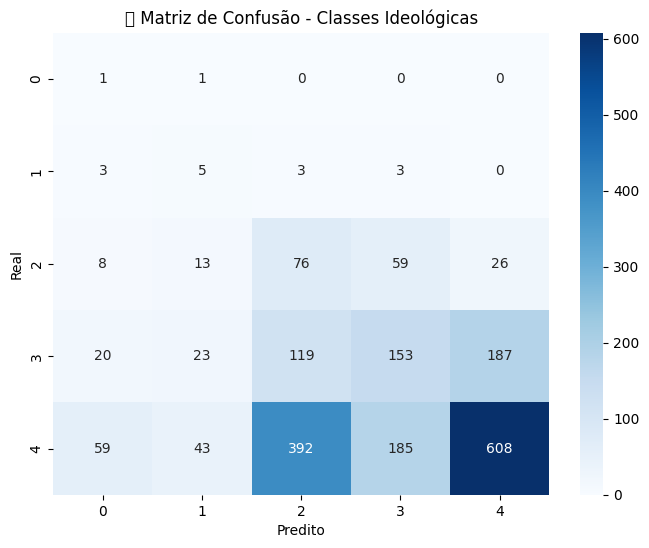

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 🔍 Avaliação
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index, data.edge_weight)
    pred = out.argmax(dim=1)

# Apenas para deputados com rótulo
true_y = data.y[data.train_mask].cpu().numpy()
pred_y = pred[data.train_mask].cpu().numpy()

# 📊 Relatório de classificação
print("📄 Classification Report:")
print(classification_report(true_y, pred_y, digits=3))

# 🧱 Matriz de confusão
cm = confusion_matrix(true_y, pred_y)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("📉 Matriz de Confusão - Classes Ideológicas")
plt.show()


In [13]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 🔍 Colocar o modelo em modo de avaliação
model.eval()
out = model(data.x, data.edge_index, data.edge_weight)

# 🧠 Predições e verdadeiros
preds = out.argmax(dim=1).cpu().numpy()
true = data.y.cpu().numpy()
mask = data.train_mask.cpu().numpy()

# 🎯 Apenas exemplos com rótulo válido
preds_valid = preds[mask]
true_valid = true[mask]

# 📊 Relatório completo
print("📄 Classification Report:")
print(classification_report(true_valid, preds_valid, zero_division=0))

# 📌 Métricas agregadas
acc = accuracy_score(true_valid, preds_valid)
prec_macro = precision_score(true_valid, preds_valid, average='macro', zero_division=0)
rec_macro = recall_score(true_valid, preds_valid, average='macro', zero_division=0)
f1_macro = f1_score(true_valid, preds_valid, average='macro', zero_division=0)

# ✅ Exibir valores
print(f"\n✅ Accuracy: {acc:.4f}")
print(f"🎯 Precision (macro): {prec_macro:.4f}")
print(f"🔁 Recall (macro): {rec_macro:.4f}")
print(f"📘 F1-score (macro): {f1_macro:.4f}")


📄 Classification Report:
              precision    recall  f1-score   support

           0       0.01      0.50      0.02         2
           1       0.06      0.36      0.10        14
           2       0.13      0.42      0.20       182
           3       0.38      0.30      0.34       502
           4       0.74      0.47      0.58      1287

    accuracy                           0.42      1987
   macro avg       0.26      0.41      0.25      1987
weighted avg       0.59      0.42      0.48      1987


✅ Accuracy: 0.4243
🎯 Precision (macro): 0.2643
🔁 Recall (macro): 0.4104
📘 F1-score (macro): 0.2471
